In [1]:
### Linear  Lassa Ridge models 
### TO Predict NYHousing using a set of Features  
### The are Type of house ,Locality , Propertyfeet, STATE , BED ,BATHROOM

In [1]:
#Loading the neccessary Packages
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge,Lasso 
from sklearn.metrics import r2_score 
import warnings
from sklearn.preprocessing import StandardScaler

In [2]:
#loadin the file to use 
df= pd.read_csv("NYHousing.csv") 


In [5]:
### Understanding the Data 

In [3]:
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [4]:
#Displaying the columns 
df.columns

Index(['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
       'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
       'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [5]:
#coverPROPERTYSQFT"])ting the Price values in to log_price 
df['log_price']= np.log10(df['PRICE'])
df['log_PSF'] = np.log10(df["PROPERTYSQFT"])
col_to_use = ["log_price","TYPE","BEDS","BATH",'log_PSF',"STATE","LOCALITY"]
df2 = df[col_to_use].copy() 
df_encoded_view = df2[col_to_use].copy()

In [6]:
#Displaying the first 5 rows df_encoded_view
df_encoded_view.head()

,log_price,TYPE,BEDS,BATH,log_PSF,STATE,LOCALITY
0,5.498311,Condo for sale,2,2.000000,3.146128,"New York, NY 10022",New York
1,8.290035,Condo for sale,7,10.000000,4.244153,"New York, NY 10019",New York
2,5.414973,House for sale,4,2.000000,3.304275,"Staten Island, NY 10312",New York
3,4.838849,Condo for sale,3,1.000000,2.648360,"Manhattan, NY 10022",New York
4,7.740363,Townhouse for sale,7,2.373861,4.151523,"New York, NY 10065",New York


In [7]:
#Visualizing the Data through the heat map 
categorical_cols = ["TYPE","STATE","LOCALITY"]
for col in categorical_cols: 
    #Calculate the average price for each unique item in the column 
    mean_price_mapper = df_encoded_view.groupby(col)["log_price"].mean()
    #Map those numbers back into the column
    df_encoded_view[col] = df_encoded_view[col].map(mean_price_mapper) 


In [8]:
#confirming change 
df_encoded_view.head()

,log_price,TYPE,BEDS,BATH,log_PSF,STATE,LOCALITY
0,5.498311,6.075159,2,2.000000,3.146128,6.096829,6.084674
1,8.290035,6.075159,7,10.000000,4.244153,6.355033,6.084674
2,5.414973,6.000772,4,2.000000,3.304275,5.971772,6.084674
3,4.838849,6.075159,3,1.000000,2.648360,6.022678,6.084674
4,7.740363,6.501192,7,2.373861,4.151523,6.502750,6.084674


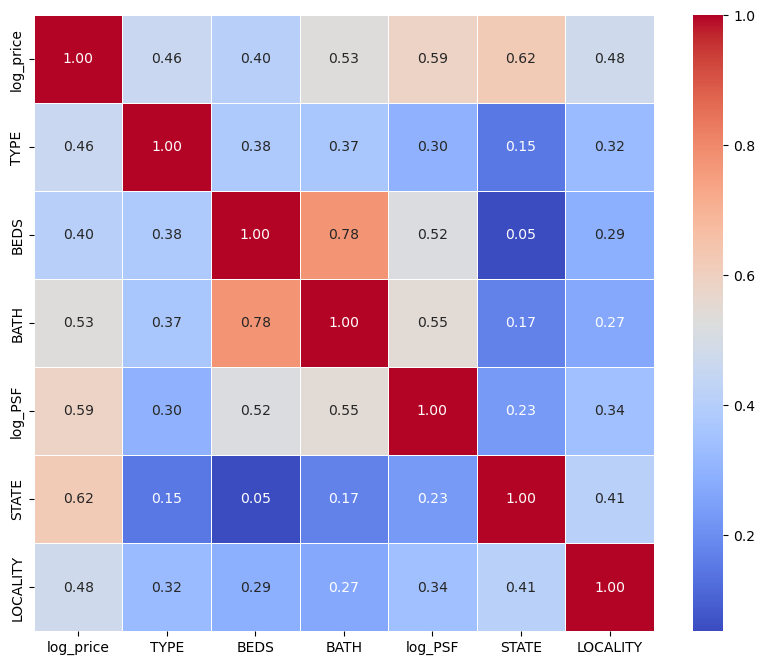

In [9]:
#Displaying the  heat map 
#coverting the raw 2d file in to the relation 2d 
cor_matrix = df_encoded_view.corr()
plt.figure(figsize=(10,8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.show()

In [54]:
# Precentage format for the heat map data
price_locality = 0.48**2
price_state = 0.62**2
price_osf = 0.59**2
price_Bath = 0.53**2
price_bed= 0.40 **2
price_type = 0.46**2
print(price_type,price_bed,price_Bath,price_osf,price_state,price_locality)


0.2116 0.16000000000000003 0.28090000000000004 0.34809999999999997 0.3844 0.2304


In [55]:
df2.head()

,log_price,TYPE,BEDS,BATH,log_PSF,STATE,LOCALITY
0,5.498311,Condo for sale,2,2.000000,3.146128,"New York, NY 10022",New York
1,8.290035,Condo for sale,7,10.000000,4.244153,"New York, NY 10019",New York
2,5.414973,House for sale,4,2.000000,3.304275,"Staten Island, NY 10312",New York
3,4.838849,Condo for sale,3,1.000000,2.648360,"Manhattan, NY 10022",New York
4,7.740363,Townhouse for sale,7,2.373861,4.151523,"New York, NY 10065",New York


In [56]:
#Spliting the feature and the target 
x= df2.iloc[: , 1:] 
y = df2.iloc[:,0]

In [57]:
#Spliting the dataset into testing and training data
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.20, random_state=0) 

In [58]:
###  Perform  Preprocessing within the training circle 

In [60]:
# Safe one hot encoding 
#grouping all the categorial set
categorial_cols= ["TYPE","STATE","LOCALITY"] 
# Expand the training set to include the binary dummy columns 
x_train_ohe = pd.get_dummies(x_train, columns=categorical_cols)

#Expanding the test data set to accept the binart dummy columns
x_test_ohe = pd.get_dummies(x_test, columns=categorical_cols) 
x_train_ohe.shape


(3840, 316)

In [61]:
#IF within the testing phrase we are making sure that phase is the only thing that it see 
# if there is another forgine material it revoults back to the training set 
#x_test_ohe = x_test_ohe.reindex(columns=x_train_ohe.columns, fill_value=0) 
#Now to save the exact structural columns list permanently user for user input later

ohe_columns_structure = x_train_ohe.columns.tolist()
x_test_aligned = x_test_ohe.reindex(columns=x_train_ohe.columns, fill_value=0)

In [62]:
#Applyinng the Feature Scaling 
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x_train_ohe) 
x_test_scaled = scaler.fit_transform(x_test_aligned) 


In [63]:
#Applying Pure Linear Regression 
lr_ohe = LinearRegression()
lr_ohe.fit(x_train_scaled, y_train) 
print(f" OHE LINEAR REGRESSION R2 : {r2_score(y_test,lr_ohe.predict(x_test_scaled))*100: .2f}%")

 OHE LINEAR REGRESSION R2 :  71.06%


In [64]:
lasso_ohe = Lasso(alpha=0.0005 , random_state=0) 
lasso_ohe.fit(x_train_scaled,y_train) 
print(f" Lasso L1 R2: {r2_score(y_test,lasso_ohe.predict(x_test_scaled))*100: .2f}%")

 Lasso L1 R2:  71.51%


In [65]:
# 3. Tuned Ridge L2 (Distributes weights evenly across high-dimensional features)
ridge_ohe = Ridge(alpha=1.0, random_state=0)
ridge_ohe.fit(x_train_scaled, y_train)
print(f"📊 OHE Optimized Ridge (L2) R²:    {r2_score(y_test, ridge_ohe.predict(x_test_scaled)) * 100:.2f}%")
print("="*40)

📊 OHE Optimized Ridge (L2) R²:    71.07%


# ==========================================
# 🏠 SYSTEM RESET: LOGICALLY ALIGNED GENERATOR
# ==========================================
print("====== 🏠 ENTER NEW HOUSE FEATURES ======")
in_type = input("Enter Property Type (e.g., Condo, House, Townhouse): ").strip()
in_beds = int(input("Number of Bedrooms: "))
in_bath = float(input("Number of Bathrooms: "))
in_sqft = float(input("Property Square Footage (PROPERTYSQFT): "))
in_state = input("Enter State (e.g., NY): ").strip()
in_locality = input("Enter Locality/Neighborhood (e.g., Manhattan): ").strip()

# 1. ENFORCE SYMMETRIC LOG BASE: Ensure this matches your training phase log base!
# If your training phase used np.log(), change this to np.log(). If it used np.log10(), keep np.log10()
transformed_sqft = np.log10(in_sqft) 

# 2. DATA TRACKING CONTRACT: Use a dictionary to explicitly link names to values
# 🌟 IMPORTANCE CHECK: Change "log_sqft_PSF" below to the EXACT name used in x_train_ohe!
raw_input_dict = {
    "TYPE": [in_type],
    "BEDS": [in_beds],
    "BATH": [in_bath],
    "log_PSF": [transformed_sqft],  
    "STATE": [in_state],
    "LOCALITY": [in_locality]
}
new_house_raw = pd.DataFrame(raw_input_dict)

# 3. Apply One-Hot Encoding
new_house_ohe = pd.get_dummies(new_house_raw, columns=categorical_cols)

# 4. DATA GOVERNANCE MASK: Force structural matrix compliance
new_house_final = new_house_ohe.reindex(columns=x_train_ohe.columns, fill_value=0)

# 5. Scale using your training-fitted parameters
new_house_z_scores = scaler.transform(new_house_final)

# 6. Generate Predictions
log_pred_ridge1 = ridge_ohe.predict(new_house_z_scores)[0]
log_pred_ridge2 = lasso_ohe.predict(new_house_z_scores)[0]
log_pred_ridge3 = lr_ohe.predict(new_house_z_scores)[0]

print("\n" + "="*40)
print("🚀 GENERALIZED MODEL MARKET PREDICTIONS")
print("="*40)
print(f"DEBUG - Raw Ridge Output: {log_pred_ridge1}")
print(f"🏠 Maxed OHE Ridge Real Price Prediction:  ${10**log_pred_ridge1:,.2f}")
print(f"DEBUG - Raw Ridge Output: {log_pred_ridge2}")
print(f"🏠 Maxed OHE Lasso Real Price Prediction:  ${10**log_pred_ridge2:,.2f}")
print(f"🏠 Maxed OHE Linear Real Price Prediction: ${10**log_pred_ridge3:,.2f}")
print("="*40)